In [1]:
#Kafka Stream lesen

raw_kafka_df = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "bd-1:9092")
    .option("subscribe", "sensor.barometer")
    .option("startingOffsets", "latest")
    .load()
)

raw_kafka_df.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



In [2]:
#JSON parsen

from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

message_schema = StructType([
    StructField("userId", StringType(), True),
    StructField("deviceId", StringType(), True),
    StructField("walkId", StringType(), True),
    StructField("sensorType", StringType(), True),
    StructField("timestamp", DoubleType(), True),
    StructField("data", StructType([
        StructField("timeSeconds", DoubleType(), True),
        StructField("pressureHpa", DoubleType(), True),
    ]), True),
])

barometer_df = (
    raw_kafka_df
    .select(
        F.col("topic"),
        F.col("partition"),
        F.col("offset"),
        F.col("timestamp").alias("kafkaTimestamp"),
        F.col("key").cast("string").alias("messageKey"),
        F.col("value").cast("string").alias("jsonValue")
    )
    .withColumn("json", F.from_json(F.col("jsonValue"), message_schema))
    .select(
        "topic",
        "partition",
        "offset",
        "kafkaTimestamp",
        "messageKey",
        "jsonValue",
        F.col("json.userId").alias("userId"),
        F.col("json.deviceId").alias("deviceId"),
        F.col("json.walkId").alias("walkId"),
        F.col("json.sensorType").alias("sensorType"),
        F.to_timestamp(F.from_unixtime(F.col("json.timestamp"))).alias("eventTime"),
        F.col("json.data.timeSeconds").alias("timeSeconds"),
        F.col("json.data.pressureHpa").alias("pressureHpa")
    )
)

barometer_df.printSchema()


root
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- kafkaTimestamp: timestamp (nullable = true)
 |-- messageKey: string (nullable = true)
 |-- jsonValue: string (nullable = true)
 |-- userId: string (nullable = true)
 |-- deviceId: string (nullable = true)
 |-- walkId: string (nullable = true)
 |-- sensorType: string (nullable = true)
 |-- eventTime: timestamp (nullable = true)
 |-- timeSeconds: double (nullable = true)
 |-- pressureHpa: double (nullable = true)



In [3]:
#Window + Watermark Analyse

windowed_barometer_df = (
    barometer_df
    .withWatermark("eventTime", "1 minute")
    .groupBy(
        F.window(F.col("eventTime"), "10 seconds", "5 seconds"),
        F.col("walkId"),
        F.col("deviceId"),
        F.col("sensorType")
    )
    .agg(
        F.count("*").alias("measurementCount"),
        F.avg("pressureHpa").alias("avgPressureHpa"),
        F.min("pressureHpa").alias("minPressureHpa"),
        F.max("pressureHpa").alias("maxPressureHpa"),
        F.stddev("pressureHpa").alias("stddevPressureHpa")
    )
    .select(
        F.col("window.start").alias("windowStart"),
        F.col("window.end").alias("windowEnd"),
        "walkId",
        "deviceId",
        "sensorType",
        "measurementCount",
        "avgPressureHpa",
        "minPressureHpa",
        "maxPressureHpa",
        "stddevPressureHpa"
    )
)

windowed_barometer_df.printSchema()

root
 |-- windowStart: timestamp (nullable = true)
 |-- windowEnd: timestamp (nullable = true)
 |-- walkId: string (nullable = true)
 |-- deviceId: string (nullable = true)
 |-- sensorType: string (nullable = true)
 |-- measurementCount: long (nullable = false)
 |-- avgPressureHpa: double (nullable = true)
 |-- minPressureHpa: double (nullable = true)
 |-- maxPressureHpa: double (nullable = true)
 |-- stddevPressureHpa: double (nullable = true)



In [4]:
#Memory Query für Echtzeit-Visualisierung starten

analysis_query = (
    windowed_barometer_df
    .writeStream
    .format("memory")
    .queryName("barometer_realtime_analysis")
    .outputMode("complete")
    .trigger(processingTime="5 seconds")
    .start()
)

print("analysis_query gestartet.")

analysis_query gestartet.


In [5]:
#Analyse-Ergebnise prüfen

spark.sql("""
    SELECT
        windowStart,
        windowEnd,
        walkId,
        measurementCount,
        avgPressureHpa,
        minPressureHpa,
        maxPressureHpa,
        stddevPressureHpa
    FROM barometer_realtime_analysis
    ORDER BY windowStart DESC
    LIMIT 20
""").show(truncate=False)

+-------------------+-------------------+------------------+----------------+-----------------+--------------+--------------+---------------------+
|windowStart        |windowEnd          |walkId            |measurementCount|avgPressureHpa   |minPressureHpa|maxPressureHpa|stddevPressureHpa    |
+-------------------+-------------------+------------------+----------------+-----------------+--------------+--------------+---------------------+
|2026-06-01 16:31:50|2026-06-01 16:32:00|walk-2026-03-04-01|7               |958.2129669142856|958.2104492   |958.2149506   |0.0017003043819617313|
|2026-06-01 16:31:45|2026-06-01 16:31:55|walk-2026-03-04-01|17              |958.2120334411766|958.2063293   |958.2149506   |0.0027047610721774615|
|2026-06-01 16:31:40|2026-06-01 16:31:50|walk-2026-03-04-01|20              |958.2062873799998|958.1974792   |958.2149506   |0.006063220599638231 |
|2026-06-01 16:31:35|2026-06-01 16:31:45|walk-2026-03-04-01|20              |958.2000541599998|958.1974792   |95

Iteration: 14/60
Anzahl Zeilen: 31


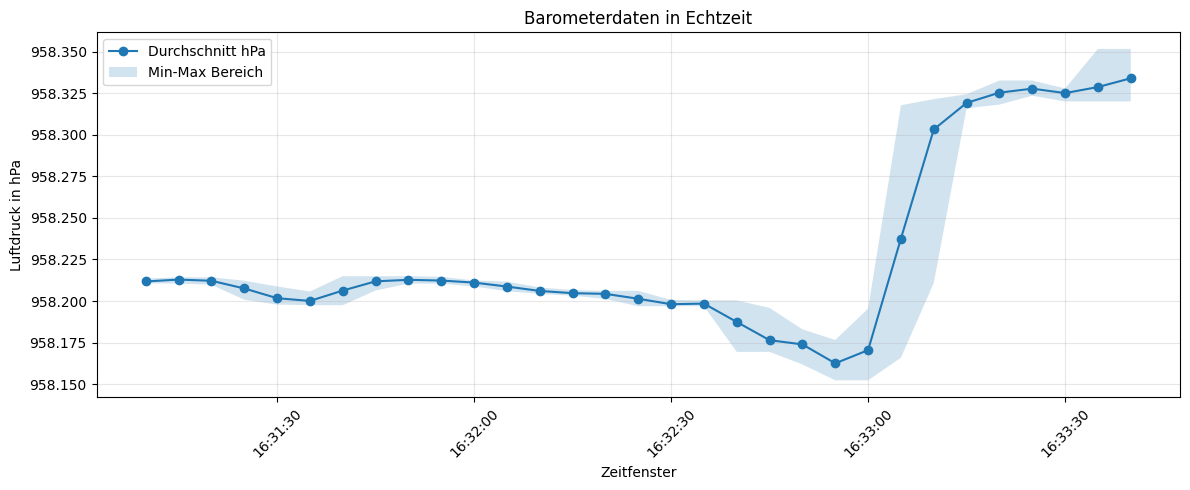

In [ ]:
#Live-Visualisierung aus Memory Tabelle

import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

for i in range(60):
    pdf = (
        spark.sql("""
            SELECT
                windowStart,
                avgPressureHpa,
                minPressureHpa,
                maxPressureHpa,
                measurementCount
            FROM barometer_realtime_analysis
            ORDER BY windowStart
        """)
        .toPandas()
    )

    clear_output(wait=True)

    print(f"Iteration: {i + 1}/60")
    print("Anzahl Zeilen:", len(pdf))

    if pdf.empty:
        print("Noch keine Daten empfangen.")
    else:
        pdf = pdf.dropna(subset=["windowStart", "avgPressureHpa"])
        pdf = pdf.sort_values("windowStart")

        plt.figure(figsize=(12, 5))
        plt.plot(pdf["windowStart"], pdf["avgPressureHpa"], marker="o", label="Durchschnitt hPa")
        plt.fill_between(
            pdf["windowStart"],
            pdf["minPressureHpa"],
            pdf["maxPressureHpa"],
            alpha=0.2,
            label="Min-Max Bereich"
        )
        plt.xlabel("Zeitfenster")
        plt.ylabel("Luftdruck in hPa")
        plt.title("Barometerdaten in Echtzeit")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    time.sleep(5)

In [ ]:
print("Aktiv:", raw_kafka_test_query.isActive)
print("Status:", raw_kafka_test_query.status)
print("Exception:", raw_kafka_test_query.exception())
print("Last Progress:", raw_kafka_test_query.lastProgress)

In [ ]:
#Nach HDFS als Parquet schreiben

#Im Terminal --> hdfs dfs -rm -r -f /data/checkpoint/bronze_sensor_barometer

bronze_query = (
    bronze_df
    .writeStream
    .format("parquet")
    .option("path", "hdfs://bd-1:9000/data/bronze/sensor_barometer")
    .option("checkpointLocation", "hdfs://bd-1:9000/data/checkpoint/bronze_sensor_barometer")
    .partitionBy("eventDate", "sensorType")
    .outputMode("append")
    .trigger(processingTime="10 seconds")
    .start()
)

print("bronze_query gestartet.")

In [ ]:
bronze_read_df = spark.read.parquet("hdfs://bd-1:9000/data/bronze/sensor_barometer")

bronze_read_df.printSchema()#HDFS-Bronze Daten lesen und zeigen

#Nach ca. 5 Sekunden:
bronze_read_df = spark.read.parquet("hdfs://bd-1:9000/data/bronze/sensor_barometer")

bronze_read_df.printSchema()
bronze_read_df.show(20, truncate=False)

#Im Terminal danach: hdfs dfs -ls -R /data/bronze/sensor_barometer
bronze_read_df.show(20, truncate=False)

#Terminal --> hdfs dfs -ls -R /data/bronze/sensor_barometer